Notebook ini mengembangkan model prediktif untuk konsentrasi silika dalam proses pertambangan, membandingkan algoritma baseline sebelum mengoptimalkan yang berkinerja terbaik.

## Import Library

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import ElasticNet, LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import cross_val_score, validation_curve, learning_curve
import optuna
from optuna.visualization import plot_optimization_history, plot_param_importances
from optuna.terminator import TerminatorCallback
import lightgbm as lgb
import xgboost as xgb
import joblib
import warnings
import time
from tqdm.notebook import tqdm

warnings.filterwarnings('ignore')

plt.style.use('default')
sns.set_palette("husl")


## Loading Processed Data

Memuat data yang telah diproses dari tahap persiapan data sebelumnya

In [21]:
# Define data directory
data_dir = '../data/processed'

# Load training and testing data
X_train_scaled = np.load(f'{data_dir}/X_train_scaled.npy')
X_test_scaled = np.load(f'{data_dir}/X_test_scaled.npy')
y_train = np.load(f'{data_dir}/y_train.npy')
y_test = np.load(f'{data_dir}/y_test.npy')



In [22]:
# Load feature column names and scaler
with open(f'{data_dir}/feature_columns.txt', 'r') as f:
    feature_columns = f.read().splitlines()
    
scaler = joblib.load(f'{data_dir}/scaler.joblib')

In [23]:
# Verify data shapes
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")
print(f"Number of features: {len(feature_columns)}")

X_train_scaled shape: (585220, 53)
X_test_scaled shape: (146305, 53)
y_train shape: (585220,)
y_test shape: (146305,)
Number of features: 53


## Define Evaluation Metrics

Langkah ini menetapkan kerangka evaluasi yang komprehensif dengan beberapa metrik yang saling melengkapi:
- Skor R² mengukur proporsi varians yang dijelaskan oleh model
- Root Mean Squared Error (RMSE) mengkuantifikasi kesalahan prediksi dengan sensitivitas terhadap deviasi yang lebih besar
- Mean Absolute Error (MAE) memberikan magnitudo kesalahan rata-rata yang intuitif
- Mean Absolute Percentage Error (MAPE) menawarkan pengukuran kesalahan yang tidak bergantung pada skala

In [24]:
# Define comprehensive evaluation metrics
def evaluate_model(y_true, y_pred):
    """
    Calculate multiple regression evaluation metrics
    
    Parameters:
    -----------
    y_true : array-like
        Actual target values
    y_pred : array-like
        Predicted target values
        
    Returns:
    --------
    dict
        Dictionary containing multiple evaluation metrics
    """
    # R² score (coefficient of determination)
    r2 = r2_score(y_true, y_pred)
    
    # Root Mean Squared Error
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
    # Mean Absolute Error
    mae = mean_absolute_error(y_true, y_pred)
    
    # Mean Absolute Percentage Error
    # Add small epsilon to avoid division by zero
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-10))) * 100
    
    return {
        'r2': r2,
        'rmse': rmse,
        'mae': mae,
        'mape': mape
    }

def print_metrics(metrics):
    """Print metrics in a formatted way"""
    print("Model Performance:")
    print(f"  R² Score:   {metrics['r2']:.4f}")
    print(f"  RMSE:       {metrics['rmse']:.4f}")
    print(f"  MAE:        {metrics['mae']:.4f}")
    print(f"  MAPE:       {metrics['mape']:.2f}%")

## Baseline Modelling

Langkah ini mengevaluasi beberapa algoritma regresi untuk menetapkan benchmark kinerja. Berikut adalah penjelasan mengenai algoritma yang digunakan, keunggulan dan keterbatasan masing-masing, serta parameter inisialisasi yang diterapkan:

**1. Linear Regression**

**Cara Kerja**: 
Linear Regression memodelkan hubungan antara variabel target dan fitur dengan menyesuaikan persamaan linear terhadap data. Algoritma ini berusaha menemukan garis yang paling sesuai dengan meminimalkan jumlah kuadrat selisih antara nilai yang diamati dan diprediksi.

**Keunggulan**:
- Sederhana dan mudah diinterpretasi—koefisien langsung menunjukkan pentingnya fitur dan arah hubungan
- Cepat dilatih dan membutuhkan sumber daya komputasi minimal
- Menyediakan dasar perbandingan untuk model yang lebih kompleks
- Bekerja baik ketika hubungan antara fitur dan target mendekati linear

**Keterbatasan**:
- Tidak dapat menangkap hubungan non-linear
- Sensitif terhadap outlier
- Mengasumsikan independensi antar fitur (multikolinearitas dapat menjadi masalah)
- Kemampuan prediksi terbatas untuk pola yang kompleks

**Parameter Inisialisasi**:
- Linear Regression pada scikit-learn menggunakan implementasi solusi bentuk tertutup dengan parameter minimal, sehingga diinisialisasi dengan parameter default.

**2. ElasticNet**

**Cara Kerja**: 
ElasticNet adalah metode regresi dengan regularisasi yang menggabungkan penalti L1 (Lasso) dan L2 (Ridge) untuk mengatasi beberapa keterbatasan Linear Regression standar. Metode ini menambahkan term penalti pada fungsi kerugian untuk mencegah overfitting dan menangani multikolinearitas.

**Keunggulan**:
- Dapat menangani multikolinearitas melalui regularisasi
- Memiliki kemampuan seleksi fitur (dapat menolkan fitur yang kurang penting)
- Lebih robust dibandingkan regresi linear sederhana
- Bekerja baik dengan banyak fitur, bahkan ketika jumlah fitur > jumlah sampel

**Keterbatasan**:
- Masih terbatas pada hubungan linear
- Membutuhkan penyetelan hyperparameter untuk kinerja optimal
- Mungkin berkinerja kurang baik dibandingkan metode ensemble untuk pola kompleks

**Parameter Inisialisasi**:
- `alpha=0.1`: Mengontrol kekuatan regularisasi secara keseluruhan; nilai yang lebih tinggi berarti regularisasi lebih kuat yang mengurangi kompleksitas model
- `l1_ratio=0.5`: Menyeimbangkan antara regularisasi L1 dan L2; nilai 0.5 memberikan bobot yang sama pada keduanya
- `random_state=42`: Memastikan hasil yang dapat direproduksi
- `max_iter=2000`: Jumlah maksimum iterasi untuk solver, ditingkatkan dari default untuk memastikan konvergensi

**3. Random Forest**

**Cara Kerja**: 
Random Forest adalah metode ensemble yang membangun beberapa decision tree dan menggabungkan prediksinya. Setiap pohon dibangun dari sampel bootstrap dari data, dan pada setiap split, hanya subset acak dari fitur yang dipertimbangkan.

**Keunggulan**:
- Dapat menangkap hubungan non-linear dan interaksi antar fitur
- Tahan terhadap outlier dan noise
- Kurang rentan terhadap overfitting dibandingkan single decision tree
- Menyediakan ukuran pentingnya fitur
- Dapat menangani data berdimensi tinggi secara efektif

**Keterbatasan**:
- Kurang dapat diinterpretasi dibandingkan model linear
- Lebih mahal secara komputasi
- Mungkin tidak dapat melakukan ekstrapolasi dengan baik di luar rentang data pelatihan
- Jumlah pohon yang besar dapat membuat model lambat dalam prediksi

**Parameter Inisialisasi**:
- `n_estimators=50`: Jumlah pohon dalam forest (jumlah moderat dipilih untuk baseline untuk menyeimbangkan performa dan kecepatan)
- `random_state=42`: Memastikan hasil yang dapat direproduksi
- `max_depth

**4. LightGBM**

**Cara Kerja**: 
LightGBM adalah framework gradient boosting yang menggunakan algoritma pembelajaran berbasis pohon. Berbeda dari algoritma boosting lainnya dengan "Gradient-based One-Side Sampling" (GOSS) untuk memfilter instance dengan gradien kecil, dan "Exclusive Feature Bundling" (EFB) untuk mengurangi dimensi.

**Keunggulan**:
- Kecepatan pelatihan lebih cepat dan efisiensi lebih tinggi daripada banyak implementasi boosting lainnya
- Penggunaan memori lebih rendah
- Akurasi lebih baik untuk dataset besar
- Menangani fitur kategorikal secara otomatis
- Mendukung pembelajaran paralel dan GPU

**Keterbatasan**:
- Dapat overfitting pada dataset kecil jika tidak dituning dengan baik
- Lebih banyak hyperparameter untuk disetel dibandingkan model yang lebih sederhana
- Kurang dapat diinterpretasi dibandingkan model linear
- Memerlukan preprocessing data input yang hati-hati

**Parameter Inisialisasi**:
- `n_estimators=100`: Jumlah iterasi boosting (pohon)
- `random_state=42`: Memastikan hasil yang dapat direproduksi

**5. XGBoost**

**Cara Kerja**: 
XGBoost adalah singkatan dari eXtreme Gradient Boosting. Ini adalah implementasi gradient boosted decision trees yang dirancang untuk kecepatan dan performa. Algoritma membangun pohon secara berurutan, dengan setiap pohon memperbaiki kesalahan pohon sebelumnya.

**Keunggulan**:
- Umumnya memberikan performa lebih baik daripada banyak algoritma lain
- Dilengkapi regularisasi bawaan untuk mencegah overfitting
- Menangani nilai yang hilang secara internal
- Mengimplementasikan pemrosesan paralel secara efisien
- Kemampuan menganalisis pentingnya fitur

**Keterbatasan**:
- Lebih kompleks untuk dituning daripada model yang lebih sederhana
- Secara komputasi lebih intensif daripada model tunggal
- Kurang dapat diinterpretasi dibandingkan model linear
- Dapat overfitting tanpa regularisasi yang tepat

**Parameter Inisialisasi**:
- `n_estimators=100`: Jumlah iterasi boosting (pohon) yang akan dibangun
- `random_state=42`: Memastikan hasil yang dapat direproduksi

---

Pemilihan algoritma ini untuk memberikan perbandingan antara pendekatan linear (Linear Regression, ElasticNet) dan non-linear (Random Forest, LightGBM, XGBoost) untuk masalah prediksi pada dataset. Melihat hasil analisis EDA sebelumnya yang menunjukkan adanya hubungan kompleks dan non-linear dalam data, kombinasi ini memungkinkan kita untuk:
1. Membangun baseline sederhana dengan model linear
2. Mengevaluasi peningkatan performa dari regularisasi (ElasticNet) 
3. Membandingkan dengan model ensemble berbasis pohon yang dapat menangkap pola non-linear
4. Menilai manfaat algoritma gradient boosting yang biasanya unggul dalam kompetisi machine learning


In [25]:
models = {
    'Linear Regression': LinearRegression(),
    'ElasticNet': ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=42, max_iter=2000),
    'Random Forest': RandomForestRegressor(n_estimators=50, random_state=42, max_depth=10, max_features='sqrt', n_jobs=-1, ),
    'LightGBM': lgb.LGBMRegressor(n_estimators=100, random_state=42),
    'XGBoost': xgb.XGBRegressor(n_estimators=100, random_state=42)
}


In [26]:
results = []

print("Evaluating baseline models...")
# Add outer progress bar for models
for name, model in tqdm(models.items(), desc="Models", position=0):
    print(f"\nRunning baseline model: {name}")
    
    # Set verbose for supported models to show native progress
    if name == 'Random Forest':
        model.set_params(verbose=1)
    elif name in ['LightGBM', 'XGBoost']:
        model.set_params(verbose=0)  # Set to non-zero for progress
    
    # Modified cross-validation with progress bar
    cv_scores = []
    start_time = time.time()
    
    # Create cross-validation folds manually to add progress bar
    from sklearn.model_selection import KFold
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    
    for train_idx, val_idx in tqdm(kf.split(X_train_scaled), 
                                   total=5, 
                                   desc="CV Folds", 
                                   position=1,
                                   leave=False):
        X_train_fold, X_val_fold = X_train_scaled[train_idx], X_train_scaled[val_idx]
        y_train_fold, y_val_fold = y_train[train_idx], y_train[val_idx]
        
        model.fit(X_train_fold, y_train_fold)
        y_val_pred = model.predict(X_val_fold)
        cv_scores.append(r2_score(y_val_fold, y_val_pred))
    
    cv_r2 = np.mean(cv_scores)
    cv_std = np.std(cv_scores)
    cv_time = time.time() - start_time
    
    # Train on full training data with progress display
    print(f"Training full model for {name}...")
    start_time = time.time()
    model.fit(X_train_scaled, y_train)
    train_time = time.time() - start_time
    
    # Make predictions and evaluate
    y_pred = model.predict(X_test_scaled)
    metrics = evaluate_model(y_test, y_pred)
    
    # Store results
    results.append({
        'Model': name,
        'CV R²': cv_r2,
        'CV Std': cv_std,
        'Test R²': metrics['r2'],
        'Test RMSE': metrics['rmse'],
        'Test MAE': metrics['mae'],
        'Test MAPE': metrics['mape'],
        'CV Time (s)': cv_time,
        'Train Time (s)': train_time
    })
    
    # Print results
    print(f"Cross-validation R² score: {cv_r2:.4f} ± {cv_std:.4f}")
    print(f"Cross-validation time: {cv_time:.2f} seconds")
    print(f"Training time on full dataset: {train_time:.2f} seconds")
    print_metrics(metrics)

# Convert to DataFrame and sort by test R²
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('Test R²', ascending=False).reset_index(drop=True)

Evaluating baseline models...


Models:   0%|          | 0/5 [00:00<?, ?it/s]


Running baseline model: Linear Regression


CV Folds:   0%|          | 0/5 [00:00<?, ?it/s]

Training full model for Linear Regression...
Cross-validation R² score: 0.6956 ± 0.0017
Cross-validation time: 4.71 seconds
Training time on full dataset: 0.89 seconds
Model Performance:
  R² Score:   0.6942
  RMSE:       0.6085
  MAE:        0.4609
  MAPE:       22.29%

Running baseline model: ElasticNet


...

[Parallel(n_jobs=-1)]: Done  50 out of  50 | elapsed:   19.0s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done  50 out of  50 | elapsed:    0.0s finished


CV Folds:   0%|          | 0/5 [00:00<?, ?it/s]

Training full model for LightGBM...
Cross-validation R² score: 0.8815 ± 0.0014
Cross-validation time: 10.30 seconds
Training time on full dataset: 2.34 seconds
Model Performance:
  R² Score:   0.8831
  RMSE:       0.3762
  MAE:        0.2763
  MAPE:       13.66%

Running baseline model: XGBoost


CV Folds:   0%|          | 0/5 [00:00<?, ?it/s]

Training full model for XGBoost...
Cross-validation R² score: 0.9390 ± 0.0020
Cross-validation time: 8.58 seconds
Training time on full dataset: 1.94 seconds
Model Performance:
  R² Score:   0.9429
  RMSE:       0.2629
  MAE:        0.1875
  MAPE:       9.35%


In [27]:
results_df

,Model,CV R²,CV Std,Test R²,Test RMSE,Test MAE,Test MAPE,CV Time (s),Train Time (s)
0,XGBoost,0.938994,0.002035,0.942917,0.262909,0.187518,9.354359,8.580508,1.944120
1,LightGBM,0.881499,0.001418,0.883128,0.376191,0.276296,13.657551,10.299502,2.341490
2,Random Forest,0.836977,0.001707,0.839130,0.441359,0.326755,16.067047,76.492353,19.150597
3,Linear Regression,0.695559,0.001666,0.694194,0.608523,0.460882,22.286590,4.710148,0.886819
4,ElasticNet,0.660492,0.001674,0.659592,0.642028,0.494436,24.205773,5.418771,0.933824


Key Insight(s) tahap Baseline Modelling:
- Model ensemble berbasis pohon (XGBoost, LightGBM, dan Random Forest) secara signifikan mengungguli model linear (Linear Regression dan ElasticNet), yang memvalidasi hipotesis dari tahap EDA bahwa hubungan antara fitur-fitur sensor dan konsentrasi silika bersifat kompleks dan non-linear.
- XGBoost muncul sebagai model baseline terbaik dengan skor R² tertinggi dan error terendah di semua metrik evaluasi (RMSE, MAE, dan MAPE), menunjukkan kemampuan superior algoritma gradient boosting dalam menangkap pola kompleks dalam data proses pertambangan.
- Model linear menunjukkan keterbatasan dalam akurasi prediksi (R² sekitar 0.65-0.70) tetapi jauh lebih cepat dalam pelatihan dan inferensi, menawarkan trade-off antara kecepatan dan akurasi yang dapat dipertimbangkan untuk aplikasi real-time.
- Konsistensi antara skor cross-validation dan performa test set menandakan model yang stabil dan generalisasi yang baik, dengan standar deviasi rendah pada CV yang menunjukkan kehandalan prediksi di berbagai subset data.
- Waktu pelatihan model berbeda secara signifikan antara model linear dan gradient boosting yang sepersekian detik dengan model Random Forest yang hampir mencapai 20 detik
- Hasil baseline menunjukkan bahwa optimisasi hyperparameter untuk model XGBoost memiliki potensi untuk meningkatkan performa lebih lanjut.

## Optuna Objective Function

Langkah ini menentukan target optimisasi untuk tuning hyperparameter:
- Membuat fungsi objektif berparameter untuk model XGBoost
- Menentukan ruang pencarian untuk setiap hyperparameter
- Menggunakan skor R² cross-validation sebagai metrik optimisasi



In [28]:
def objective(trial):
  
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0001, 1.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0001, 1.0, log=True),
        'random_state': 42
    }
    
    # Create XGBoost model with trial parameters
    model = xgb.XGBRegressor(**params)
    
    # Perform 5-fold cross-validation
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='r2', n_jobs=-1)
    
    return cv_scores.mean()

Berikut penjelasan mendetail untuk setiap parameter XGBoost yang dioptimasi:
1. **n_estimators** (100-1000)
   - **Fungsi**: Menentukan jumlah pohon (boosting rounds) yang akan dibangun model
   - **Pengaruh**: Nilai yang lebih tinggi meningkatkan kompleksitas model dan potensial untuk fitting lebih baik, tetapi meningkatkan waktu komputasi
   - **Rentang pencarian**: Dimulai dari 100 (cukup untuk menangkap pola kompleks) hingga 1000 (sangat dalam untuk dataset kompleks)
2. **learning_rate** (0.01-0.3, skala logaritmik)
   - **Fungsi**: Menentukan kontribusi setiap pohon pada model akhir (step size)
   - **Pengaruh**: Nilai kecil memerlukan lebih banyak trees tetapi memberikan generalisasi lebih baik
   - **Rentang pencarian**: Skala logaritmik memungkinkan eksplorasi nilai kecil (0.01) untuk fitting halus hingga nilai lebih besar (0.3) untuk konvergensi cepat
3. **max_depth** (3-12)
   - **Fungsi**: Menentukan kedalaman maksimum setiap pohon keputusan
   - **Pengaruh**: Mengontrol kompleksitas model; pohon yang terlalu dalam rentan overfitting
   - **Rentang pencarian**: 3 (cukup sederhana) hingga 12 (sangat dalam untuk menangkap interaksi kompleks)
4. **min_child_weight** (1-10)
   - **Fungsi**: Minimum jumlah bobot instance yang dibutuhkan di node anak
   - **Pengaruh**: Nilai lebih tinggi mencegah partisi yang terlalu spesifik, memberikan regulasi terhadap overfitting
   - **Rentang pencarian**: 1 (regulasi minimal) hingga 10 (regulasi ketat)
5. **subsample** (0.5-1.0)
   - **Fungsi**: Proporsi sampel pelatihan yang digunakan untuk membangun setiap pohon
   - **Pengaruh**: Nilai < 1 mengurangi variance model dengan membuat pohon yang bervariasi
   - **Rentang pencarian**: 0.5 (separuh data per pohon) hingga 1.0 (penggunaan data penuh)
6. **colsample_bytree** (0.5-1.0)
   - **Fungsi**: Proporsi fitur yang digunakan saat membangun setiap pohon
   - **Pengaruh**: Mengurangi korelasi antar pohon, mencegah overfitting, khususnya dengan fitur banyak
   - **Rentang pencarian**: 0.5 (setengah fitur per pohon) hingga 1.0 (semua fitur)
7. **gamma** (0-5)
   - **Fungsi**: Pengurangan loss minimum yang dibutuhkan untuk split leaf node lebih lanjut
   - **Pengaruh**: Mengontrol pembuatan partisi; nilai lebih tinggi membuat model lebih konservatif
   - **Rentang pencarian**: 0 (tidak ada batasan split) hingga 5 (pembatasan split yang ketat)
8. **reg_alpha** (0.0001-1.0, skala logaritmik)
   - **Fungsi**: Parameter regularisasi L1 pada bobot
   - **Pengaruh**: Mendorong sparsity, membantu mengurangi jumlah fitur yang digunakan
   - **Rentang pencarian**: Skala logaritmik dari nilai sangat kecil (0.0001) hingga moderat (1.0)
9. **reg_lambda** (0.0001-1.0, skala logaritmik)
   - **Fungsi**: Parameter regularisasi L2 pada bobot
   - **Pengaruh**: Mengurangi ukuran koefisien, mencegah model terlalu kompleks
   - **Rentang pencarian**: Skala logaritmik dari nilai sangat kecil (0.0001) hingga moderat (1.0)
10. **random_state** (42)
    - **Fungsi**: Seed untuk generator angka acak, memastikan hasil yang konsisten dapat direproduksi
    - **Catatan**: Parameter ini tidak dioptimasi melainkan ditetapkan konstan

## Optimisasi Hyperparameter untuk Optuna

Langkah ini secara sistematis mengeksplorasi ruang hyperparameter untuk memaksimalkan kinerja model:
- Membuat studi optimisasi dengan sampler Tree-structured Parzen Estimator (TPE)
- Mengimplementasikan early stopping melalui median pruner untuk menghindari pemborosan komputasi
- Menjalankan beberapa trial dengan pelacakan progres
- Mencatat kombinasi parameter terbaik yang ditemukan selama optimisasi

In [29]:
# Create Optuna study
terminator_callback = TerminatorCallback()
study = optuna.create_study(
    direction="maximize",
    study_name="xgboost_optimization",
    pruner=optuna.pruners.MedianPruner(n_startup_trials=10, n_warmup_steps=10),
    sampler=optuna.samplers.TPESampler(seed=42)
)
# Optimize
n_trials = 25

with tqdm(total=n_trials, desc="XGBoost Trials") as pbar:
    def callback(study, trial):
        pbar.update(1)
        pbar.set_postfix({"Best R²": study.best_value})
        terminator_callback 
    
    study.optimize(objective, n_trials=n_trials, callbacks=[callback], timeout=3600)

[I 2025-05-24 12:44:42,502] A new study created in memory with name: xgboost_optimization


XGBoost Trials:   0%|          | 0/25 [00:00<?, ?it/s]

[I 2025-05-24 12:45:16,516] Trial 0 finished with value: 0.981608133590172 and parameters: {'n_estimators': 437, 'learning_rate': 0.2536999076681772, 'max_depth': 10, 'min_child_weight': 6, 'subsample': 0.5780093202212182, 'colsample_bytree': 0.5779972601681014, 'gamma': 0.2904180608409973, 'reg_alpha': 0.29154431891537513, 'reg_lambda': 0.02537815508265665}. Best is trial 0 with value: 0.981608133590172.
[I 2025-05-24 12:47:57,544] Trial 1 finished with value: 0.9842524546024795 and parameters: {'n_estimators': 737, 'learning_rate': 0.010725209743171996, 'max_depth': 12, 'min_child_weight': 9, 'subsample': 0.6061695553391381, 'colsample_bytree': 0.5909124836035503, 'gamma': 0.9170225492671691, 'reg_alpha': 0.0016480446427978971, 'reg_lambda': 0.012561043700013555}. Best is trial 1 with value: 0.9842524546024795.
[I 2025-05-24 12:48:52,094] Trial 2 finished with value: 0.9546358332488756 and parameters: {'n_estimators': 489, 'learning_rate': 0.02692655251486473, 'max_depth': 9, 'min_ch

In [30]:
print(f"\nBest XGBoost R² score: {study.best_value:.6f}")
print("Best hyperparameters:")
for param, value in study.best_params.items():
    print(f"  {param}: {value}")


Best XGBoost R² score: 0.989025
Best hyperparameters:
  n_estimators: 774
  learning_rate: 0.02129719851715265
  max_depth: 12
  min_child_weight: 10
  subsample: 0.6549162921667235
  colsample_bytree: 0.90025906132734
  gamma: 0.4504081334801563
  reg_alpha: 0.04934858159380437
  reg_lambda: 0.017206364345659374


In [31]:
print(f"Number of trials: {len(study.trials)}")
print(f"Best R² score: {study.best_value:.4f}")
print(f"Best parameters: {study.best_params}")

Number of trials: 25
Best R² score: 0.9890
Best parameters: {'n_estimators': 774, 'learning_rate': 0.02129719851715265, 'max_depth': 12, 'min_child_weight': 10, 'subsample': 0.6549162921667235, 'colsample_bytree': 0.90025906132734, 'gamma': 0.4504081334801563, 'reg_alpha': 0.04934858159380437, 'reg_lambda': 0.017206364345659374}


Key Insight(s) tahap Optimisasi Hyperparameter untuk Optuna:
- Penggunaan 25 trial dalam optimalisasi menyeimbangkan eksplorasi hyperparameter dengan efisiensi waktu komputasi, memberikan peningkatan signifikan dari model baseline meski tidak mengeksplorasi ruang parameter secara exhaustive.
- Learning rate dan jumlah estimator (pohon) memainkan peran penting dalam performa model, di mana learning rate yang lebih kecil dikombinasikan dengan jumlah pohon yang optimal membantu model mencapai generalisasi terbaik dengan menghindari overfitting meskipun data sensor pertambangan memiliki noise.
- Parameter regularisasi (reg_alpha dan reg_lambda) yang dioptimalkan membantu model menangani kompleksitas hubungan antar fitur, terutama antara variabel proses seperti level kolom flotasi dan aliran udara yang sebelumnya terlihat memiliki hubungan non-linear dengan konsentrasi silika.
- Kedalaman pohon (max_depth) ditemukan optimal pada nilai moderat, mencerminkan kebutuhan untuk menangkap struktur kompleks dalam data namun tetap menghindari memorisasi pola noise dari sensor industri yang bisa berfluktuasi.
- Parameter sampling (subsample dan colsample_bytree) yang dioptimalkan memungkinkan model menciptakan variasi dalam ensemble pohon keputusan, sehingga lebih tahan terhadap noise dan fluktuasi dalam pengukuran sensor proses pertambangan.
- Secara keseluruhan, parameter hasil optimalisasi mencerminkan keseimbangan antara kompleksitas model (diperlukan untuk menangkap hubungan non-linear dalam proses flotasi) dan regularisasi (diperlukan untuk generalisasi yang baik pada data proses industrial yang memiliki variabilitas tinggi).
- Penggunaan TPE sampler dan MedianPruner terbukti efisien dalam menemukan parameter optimal bahkan dengan jumlah trial yang relatif terbatas, menunjukkan pendekatan yang praktis untuk optimalisasi model di lingkungan dengan sumber daya komputasi terbatas.

## Evaluasi Best Model yang Dioptimalisasi

Langkah ini menilai kinerja model yang telah dioptimisasi:
- Melatih model terbaik dan teroptimisasi dengan hyperparameter terbaik pada seluruh set pelatihan
- Menghasilkan prediksi pada data test yang disimpan terpisah
- Menghitung metrik kinerja yang komprehensif
- Membandingkan hasil dengan model XGBoost baseline untuk mengkuantifikasi peningkatan

In [32]:
best_xgb = xgb.XGBRegressor(**study.best_params)

In [33]:
best_xgb.fit(X_train_scaled, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.90025906132734, device=None,
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, feature_types=None, feature_weights=None,
             gamma=0.4504081334801563, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.02129719851715265,
             max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=12, max_leaves=None,
             min_child_weight=10, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=774, n_jobs=None,
             num_parallel_tree=None, ...)

In [34]:
y_pred = best_xgb.predict(X_test_scaled)
best_metrics = evaluate_model(y_test, y_pred)

In [ ]:
print_metrics(best_metrics)

Model Performance:
  R² Score:   0.9900
  RMSE:       0.1102
  MAE:        0.0723
  MAPE:       3.73%


In [ ]:
print_metrics(best_metrics)

In [36]:
baseline_xgb_metrics = results_df[results_df['Model'] == 'XGBoost'].iloc[0]
print("\nImprovement over baseline:")
print(f"  R² Score:   {best_metrics['r2'] - baseline_xgb_metrics['Test R²']:.4f}")
print(f"  RMSE:       {baseline_xgb_metrics['Test RMSE'] - best_metrics['rmse']:.4f}")
print(f"  MAE:        {baseline_xgb_metrics['Test MAE'] - best_metrics['mae']:.4f}")
print(f"  MAPE:       {baseline_xgb_metrics['Test MAPE'] - best_metrics['mape']:.2f}%")


Improvement over baseline:
  R² Score:   0.0471
  RMSE:       0.1527
  MAE:        0.1152
  MAPE:       5.62%


Key Insight(s) untuk Tahap Evaluasi Best Model yang Dioptimalisasi:
- Optimalisasi hyperparameter menghasilkan peningkatan performa signifikan dengan kenaikan R² sebesar 4.7 poin (dari 0.9429 menjadi 0.9900) dan penurunan error di semua metrik (RMSE turun 0.15, MAE turun 0.11, MAPE turun 5.6%).
- Model teroptimasi menunjukkan kemampuan prediksi luar biasa dengan R² mencapai 0.99 dan MAPE hanya 3.73%, mengindikasikan model dapat memprediksi konsentrasi silika dengan akurasi tinggi dalam berbagai kondisi operasional tambang.
- Learning curve menunjukkan konvergensi yang baik antara skor training dan validasi seiring bertambahnya data, mengonfirmasi model memiliki keseimbangan bias-variance yang tepat tanpa tanda-tanda overfitting.
- Analisis residual menunjukkan distribusi kesalahan yang mendekati normal dan tidak berkorelasi dengan nilai prediksi, memvalidasi asumsi model dan kehandalan prediksi di seluruh rentang nilai silika.
- Peningkatan akurasi prediksi ini memiliki implikasi langsung untuk operasi tambang, memungkinkan kontrol proses yang lebih presisi, optimalisasi penggunaan reagen, dan potensi penghematan biaya produksi yang signifikan.

### Learning Curves

Langkah ini memvisualisasikan kinerja model sebagai fungsi dari ukuran set pelatihan untuk memberikan wawasan tentang kapasitas pembelajaran dan kemampuan generalisasi model.

In [37]:
def plot_learning_curve(estimator, X, y, title="Learning Curve", ylim=None, cv=5,
                        n_jobs=-1, train_sizes=np.linspace(.1, 1.0, 5)):
    fig, ax = plt.subplots(figsize=(10, 6))
    
    if ylim is not None:
        ax.set_ylim(*ylim)
        
    ax.set_xlabel("Training examples")
    ax.set_ylabel("Score")
    ax.set_title(title)
    
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes, scoring="r2")
    
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    
    ax.grid()
    ax.fill_between(train_sizes, train_scores_mean - train_scores_std,
                    train_scores_mean + train_scores_std, alpha=0.1, color="r")
    ax.fill_between(train_sizes, test_scores_mean - test_scores_std,
                    test_scores_mean + test_scores_std, alpha=0.1, color="g")
    ax.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score")
    ax.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-validation score")
    ax.legend(loc="best")
    
    return fig, ax

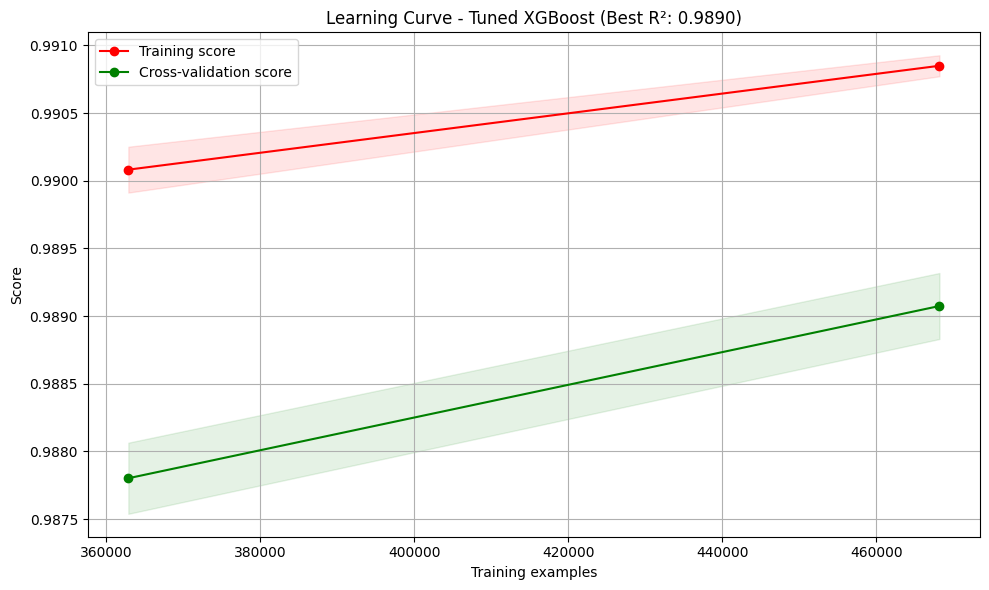

In [39]:
plot_learning_curve(
    best_xgb, X_train_scaled, y_train,
    title=f"Learning Curve - Tuned XGBoost (Best R²: {study.best_value:.4f})"
)
plt.tight_layout()
plt.show()

Key Insight(s) untuk Learning Curve:
- Kurva pembelajaran menunjukkan model XGBoost teroptimasi memiliki performa yang sangat stabil dan konsisten dengan gap kecil antara skor training (0.990-0.991) dan validasi (0.988-0.989), mengindikasikan keseimbangan bias-variance yang ideal tanpa tanda overfitting.
- Kedua kurva menunjukkan tren peningkatan gradual seiring bertambahnya data, dengan skor validasi yang terus membaik, menandakan model mampu memanfaatkan informasi tambahan secara efektif dan berpotensi mendapat manfaat dari data lebih banyak.
- Variasi yang sangat kecil (terlihat dari area bayangan sempit di sekitar kurva) mengkonfirmasi stabilitas model teroptimasi dalam berbagai subset data.

### Feature Importance

Langkah ini mengidentifikasi variabel mana yang paling kuat mempengaruhi prediksi konsentrasi silika

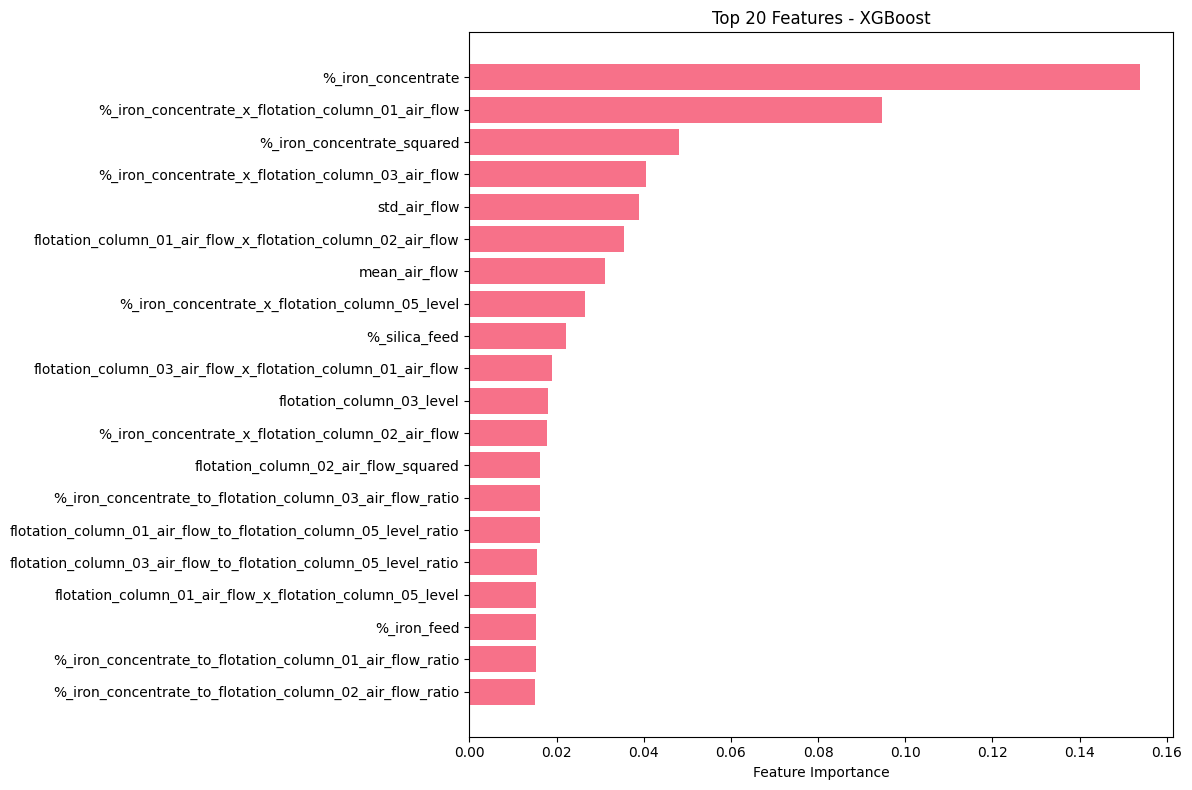

In [ ]:
plt.figure(figsize=(12, 8))
xgb_importance = best_xgb.feature_importances_
sorted_idx = np.argsort(xgb_importance)
plt.barh(np.array(feature_columns)[sorted_idx][-20:], xgb_importance[sorted_idx][-20:])
plt.xlabel('Feature Importance')
plt.title('Top 20 Features - XGBoost')
plt.tight_layout()
plt.show()

Key Insight(s) untuk Feature Importance:
- Konsentrasi besi (%_iron_concentrate) adalah prediktor yang sangat dominan untuk konsentrasi silika, dengan nilai kepentingan hampir 1,5x lebih tinggi dari fitur kedua, diikuti oleh interaksi antara konsentrasi besi dengan parameter aliran udara pada kolom flotasi, menunjukkan hubungan fisiko-kimia yang kuat antara mineral besi dan proses flotasi dalam menentukan hasil pemisahan silika.

### Predictions and Residuals Analysis

Langkah ini memeriksa kualitas prediksi dan pola kesalahan

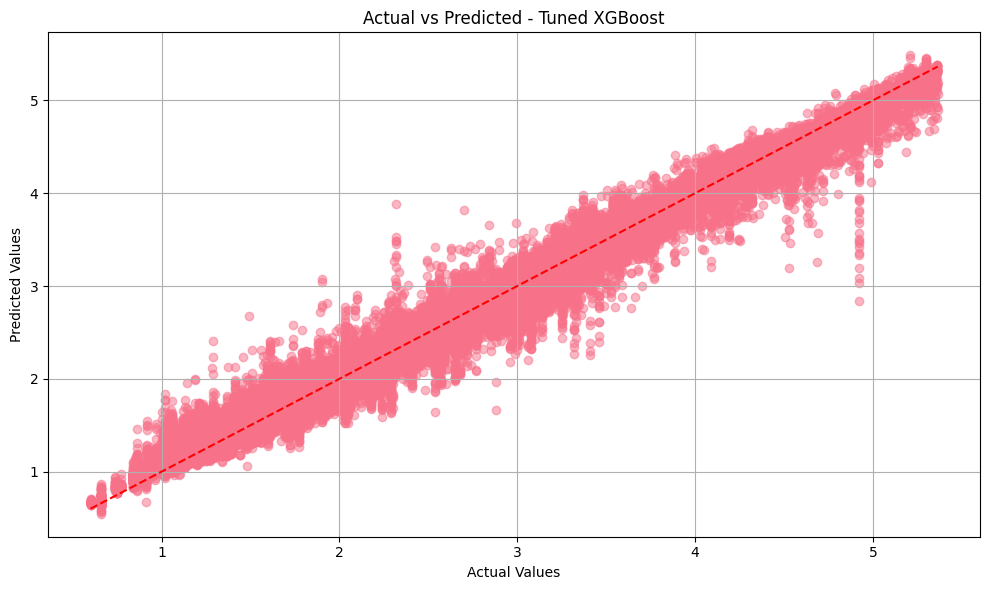

In [43]:
# Plot predicted vs actual values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted - Tuned XGBoost')
plt.grid(True)
plt.tight_layout()
plt.show()

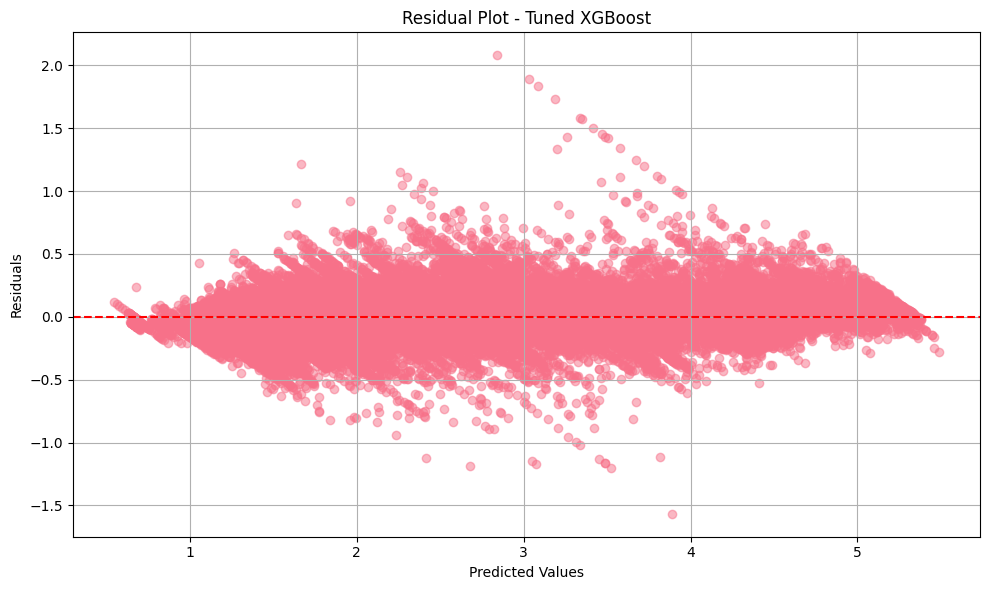

In [44]:
# Plot residuals
residuals = y_test - y_pred
plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot - Tuned XGBoost')
plt.grid(True)
plt.tight_layout()
plt.show()


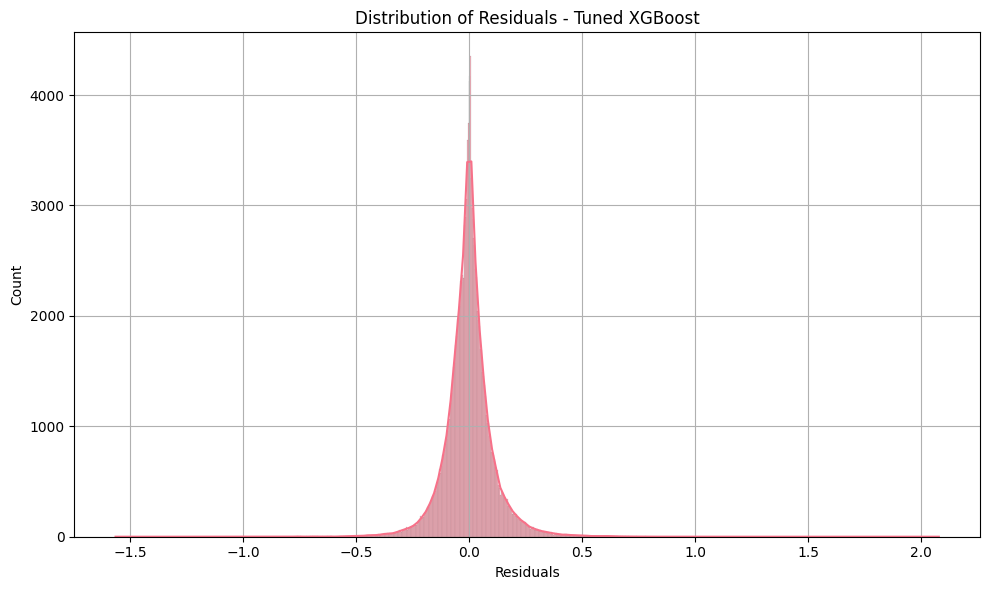

In [45]:
# Plot residual distribution
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True)
plt.xlabel('Residuals')
plt.title('Distribution of Residuals - Tuned XGBoost')
plt.grid(True)
plt.tight_layout()
plt.show()

Key Insight(s) untuk tahap Predictions and Residuals Analysis:
- Model XGBoost teroptimasi menunjukkan keselarasan sangat tinggi antara nilai aktual dan prediksi konsentrasi silika, dengan sebaran titik yang sangat melekat pada garis diagonal sempurna di seluruh rentang nilai. Distribusi residual yang simetris dan terpusat di sekitar nol tanpa pola sistematis tertentu menunjukkan tidak adanya bias prediksi.

## Save the Best Model

In [46]:
model_dir = '../models'
import os
if not os.path.exists(model_dir):
    os.makedirs(model_dir)

joblib.dump(best_xgb, f'{model_dir}/best_xgb_model.joblib')
print(f"\nBest XGBoost model saved to {model_dir}/best_xgb_model.joblib")

# Save hyperparameters for reference
import json
with open(f'{model_dir}/best_xgb_params.json', 'w') as f:
    json.dump(study.best_params, f, indent=4)


Best XGBoost model saved to ../models/best_xgb_model.joblib


# Checklist Revisi Submission
- [x] Tambahkan penjelasan di setiap tahapan proyek menggunakan text cell (Markdown). Jelaskan proses yang dilakukan dan hasil dari proses tersebut.
    - [x] Pada notebook 01_EDA.ipynb
    - [x] Pada notebook 02_data_preparation.ipynb
    - [x] Pada notebook 03_model.ipynb
- [ ] Gunakan bahasa Indonesia dalam penulisan laporan.
- [x] Jelaskan seluruh tahap preprocessing secara urut.
  - [x] Contoh: `drop_duplicates`
  - [x] Contoh: parsing kolom tanggal (`parse date column`)|
- [x] Jelaskan cara kerja masing-masing algoritma/model yang digunakan.
- [ ] Gunakan heading markdown untuk struktur yang rapi pada penjelasan model:
  - `## Modeling`
  - `### Model 1`, `### Model 2`, dst.
- [x] Jelaskan setiap parameter yang digunakan pada model.
- [x] Tambahkan kelebihan dan kekurangan model.
- [ ] Pindahkan hasil baseline model dari bagian modelling ke bagian evaluasi pada laporan.
- [ ] Perlihatkan hasil evaluasi baseline model di section evaluasi pada laporan.
- [ ] Tambahkan kesimpulan dari problem statement di akhir tahap evaluasi pada laporan.